# We stopped a training run for the wrong reason

### and nearly published a number two and a half times too confident

---

Three weeks ago we halted a fine-tuning procedure because round 4 made our model
worse. We wrote down why: the reweighting had overshot. We reported the evidence
at **t = −7.8**.

Two days of trying to break that result produced three findings, and each is a
different kind of mistake:

<br>

> ### $\color{#c0392b}{\textsf{1. The reason was wrong.}}$
> We re-ran the round with the reweighting **removed entirely**. It got
> *slightly worse*, not better. It was never the weights.
>
> ### $\color{#c0392b}{\textsf{2. The confidence was wrong.}}$
> t = −7.8 is really **t ≈ −3.3**. We had never checked whether our statistical
> test worked. Two of the three tests we were using fire **harder on data with
> no effect in it** than on the real thing.
>
> ### $\color{#c0392b}{\textsf{3. Two of our three metrics are blind.}}$
> They cannot see the thing we say we are measuring. Not "noisy" — **provably
> blind**, to sixteen decimal places.

<br>

The direction of the original finding survives all of it. Nothing else does.

---

## First, what are we even doing?

We have a model that **writes fake stock-market activity**. You give it the last
few hundred real orders from a real trading day, and it invents what happens
next — order by order, the way a language model invents the next word.

The test is simple: **if you look at the prices it produces, do they move like
real prices?** Not the same prices — nobody can predict those. The same
*character* of movement. Same typical size of swing, same shape of the rare
large jump.

One number captures most of it:

$$
R \;=\; \frac{\text{how much the model's prices swing}}{\text{how much real prices swing}}
$$

**R = 1 is perfect.** Below 1, the model is too calm — it produces a market
that is quieter than the real one. That is the failure mode we have.

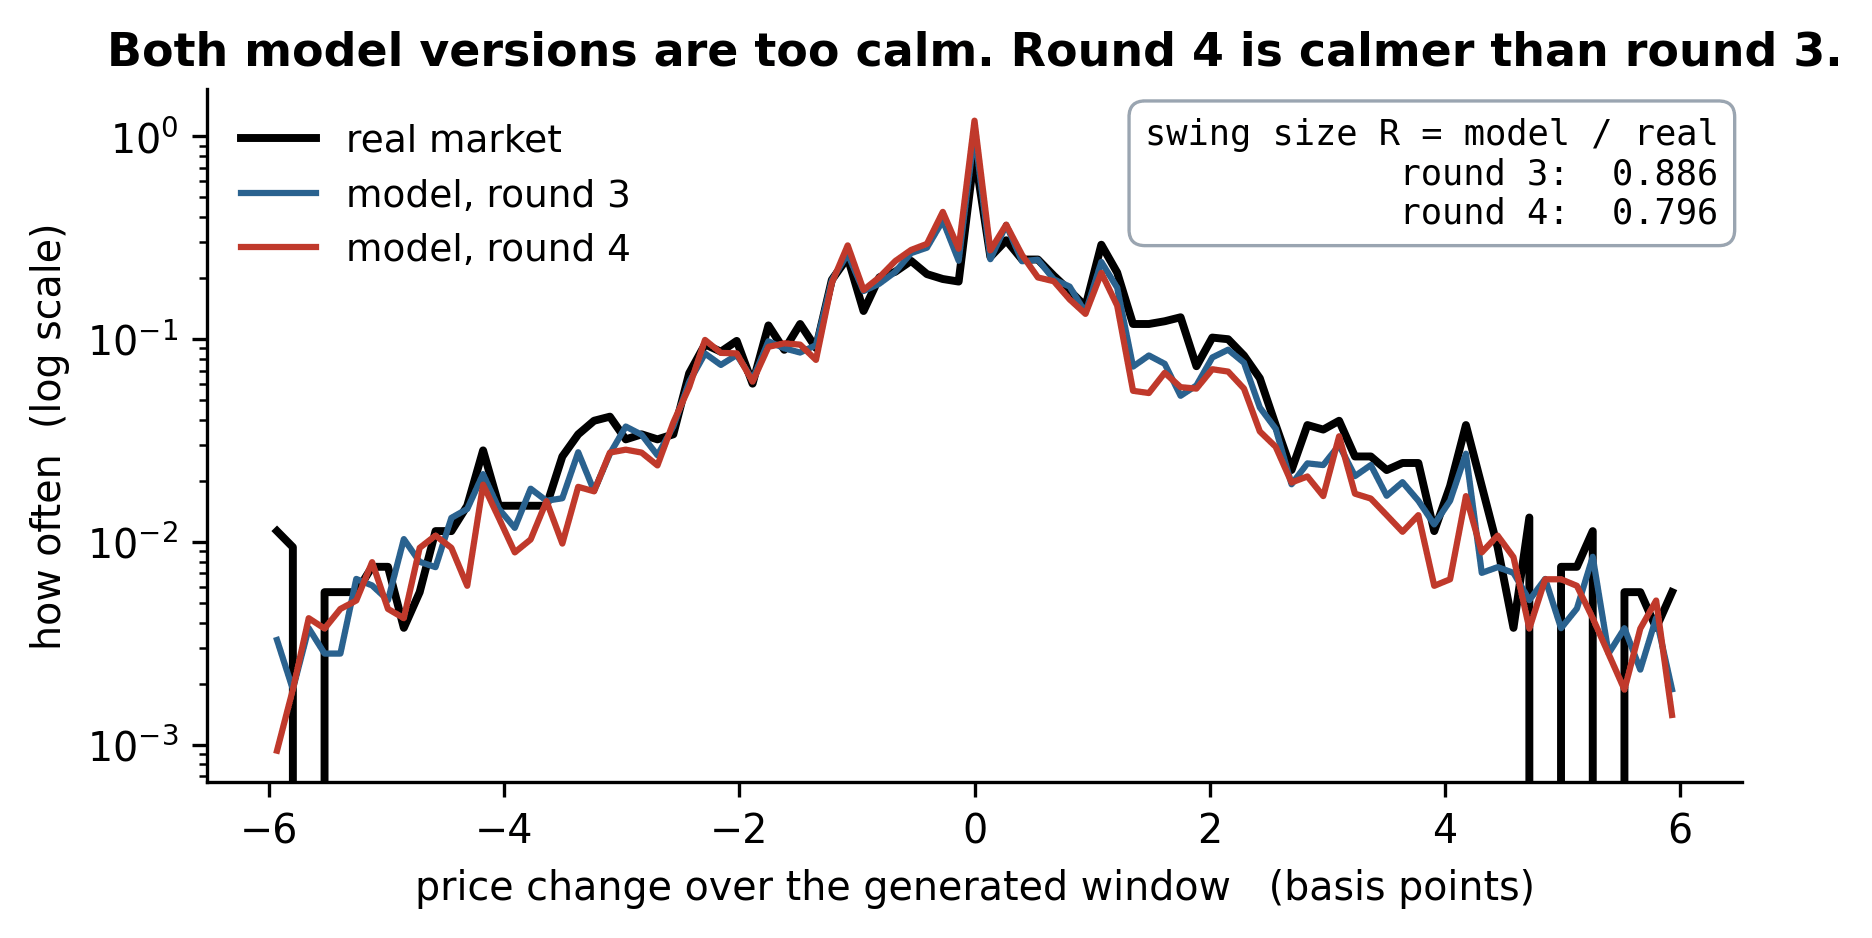

In [2]:
# t1_what_we_measure.png

**Figure 1 — What the model is asked to do, and
where it falls short.** Each curve is the distribution of price changes over a
generated window of 250 market messages, pooled over 8 large US stocks and 20
trading days in January 2026 (8,000 real windows; 16,000 generated per model
version). The horizontal axis is the price change in basis points — one hundredth
of one percent. The vertical axis is log-scaled so the rare large moves, which
matter most, stay visible. **Black is the real market. Blue and red are two
versions of the model.** Both model curves are narrower than black: the model
generates a market that is too calm. R is the ratio of the model's swing size to
the real one, where 1.000 would be perfect. Round 4 (red, R = 0.79) is further
from 1 than round 3 (blue, R = 0.87) — that gap is the finding this talk is
about.

---

## The original claim, and why we believed it

Round 4 was supposed to improve the model. It made R **worse on all eight
stocks**, without exception. We reported

$$
\Delta R \;=\; -0.081, \qquad t = -7.8
$$

A `t` of −7.8 means, loosely, *"this is eight standard errors from zero — it
could not be chance."*

We stopped the procedure and wrote down the cause: the **reweighting** step had
overshot. That name went into the record.

Both halves of that sentence turned out to be wrong.

---

## The idea that unravelled it: test your test

> **Before you trust a thermometer, put it in ice water.**
> If it reads 40°, the problem is the thermometer, not the water.

Nobody had ever put our statistical test in ice water.

Here is the ice water. Our model generates with a random seed. Take **one single
model**, generate with ten different seeds, and split those ten into two groups
of four. Compare the groups.

**The answer has to be zero.** It is the same model. Any difference is pure
randomness.

There are **1,575** ways to make that split. We ran every one of them through
each of our candidate tests, and asked: *how big a result does this test report
when the true answer is known to be nothing?*

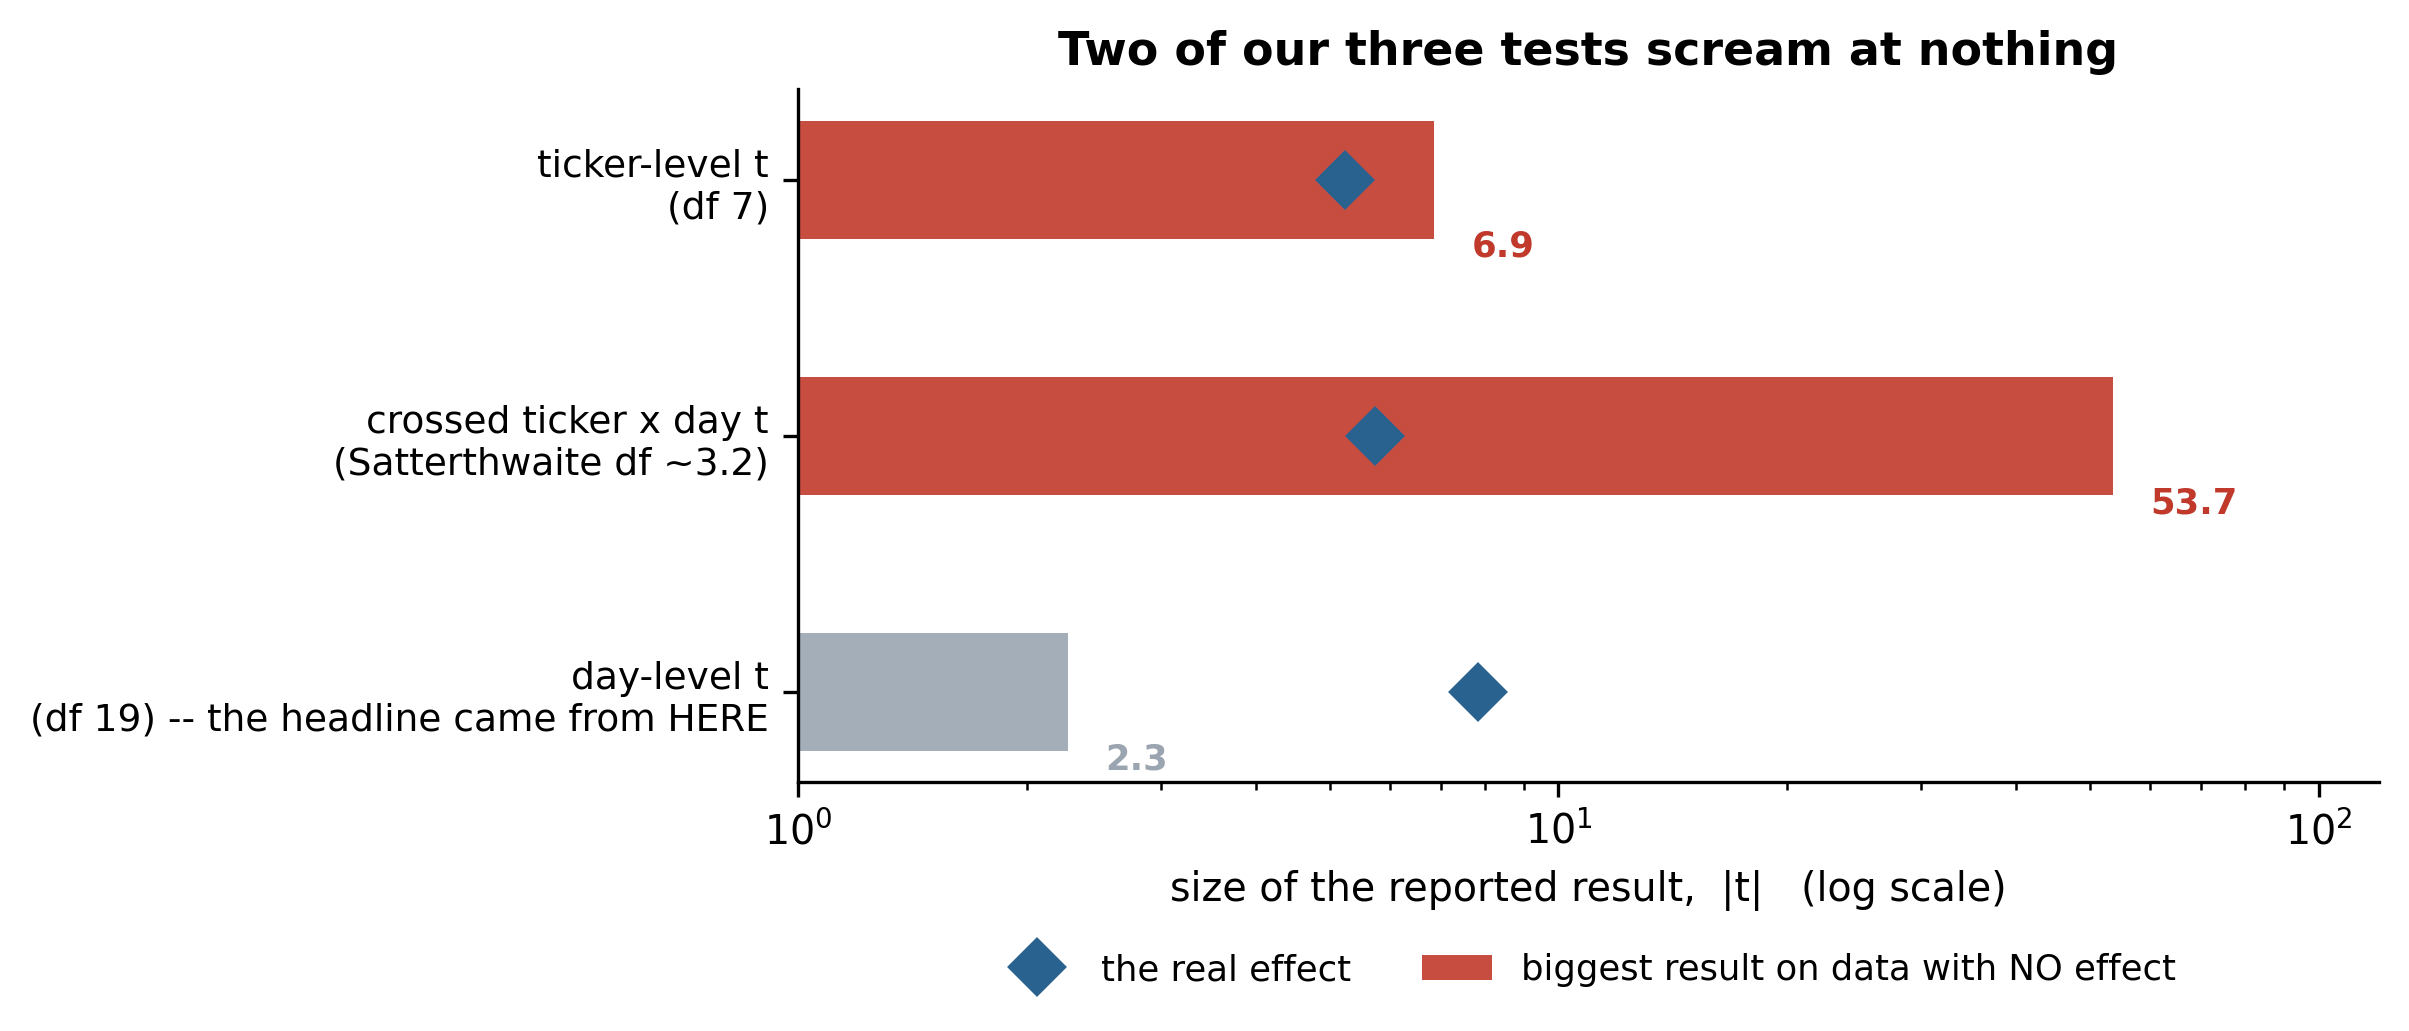

In [6]:
# t2_calibration.png

**Figure 2 — Putting three statistical tests in ice
water.** We built 1,575 comparisons whose true answer is exactly zero: one single
model, generating with different random seeds, split into two groups. Any
difference between the groups is pure chance. **Red bars show the largest result
each test reported across those 1,575 no-effect comparisons; the blue diamond is
what the same test reports on the real round-3-versus-round-4 comparison.** A
usable test must have its red bar well to the left of its blue diamond. The
ticker-level t reaches |t| = 6.9 on data containing nothing at all — larger than the
real effect it was used to certify. The crossed model, proposed as the fix, reaches
|t| = 53.7 and additionally fails to produce a valid answer at all in 42 of the 1,575
fits. **Our headline t = −7.8 came from the day-level test, and that is the one test
here that is conservative**: its null spread is 0.75 and it never exceeded 2.27, so the
two tests that misbehave are not the ones the headline rested on. The correction to the
headline is therefore about the unit of replication, not about a test that fired on
noise. Only the day-level test stays below its diamond, and
it does so with room to spare, which is why every number later in this talk uses
it.

---

## So what is the effect, really?

Once you throw out the broken tests and compare against the right yardstick —
that same *"one model, different seeds"* spread — the finding **survives, but
smaller and much less certain**:

| | reported in the record | after correction |
|---|---:|---:|
| effect on R | −0.081 | **−0.068** |
| how sure | t = −7.8 | **t = −3.3** |
| degrees of freedom | 19 | **7** |

<br>

And there is one piece of evidence that needs **no statistics at all** — no
test, no assumptions, nothing to argue about.

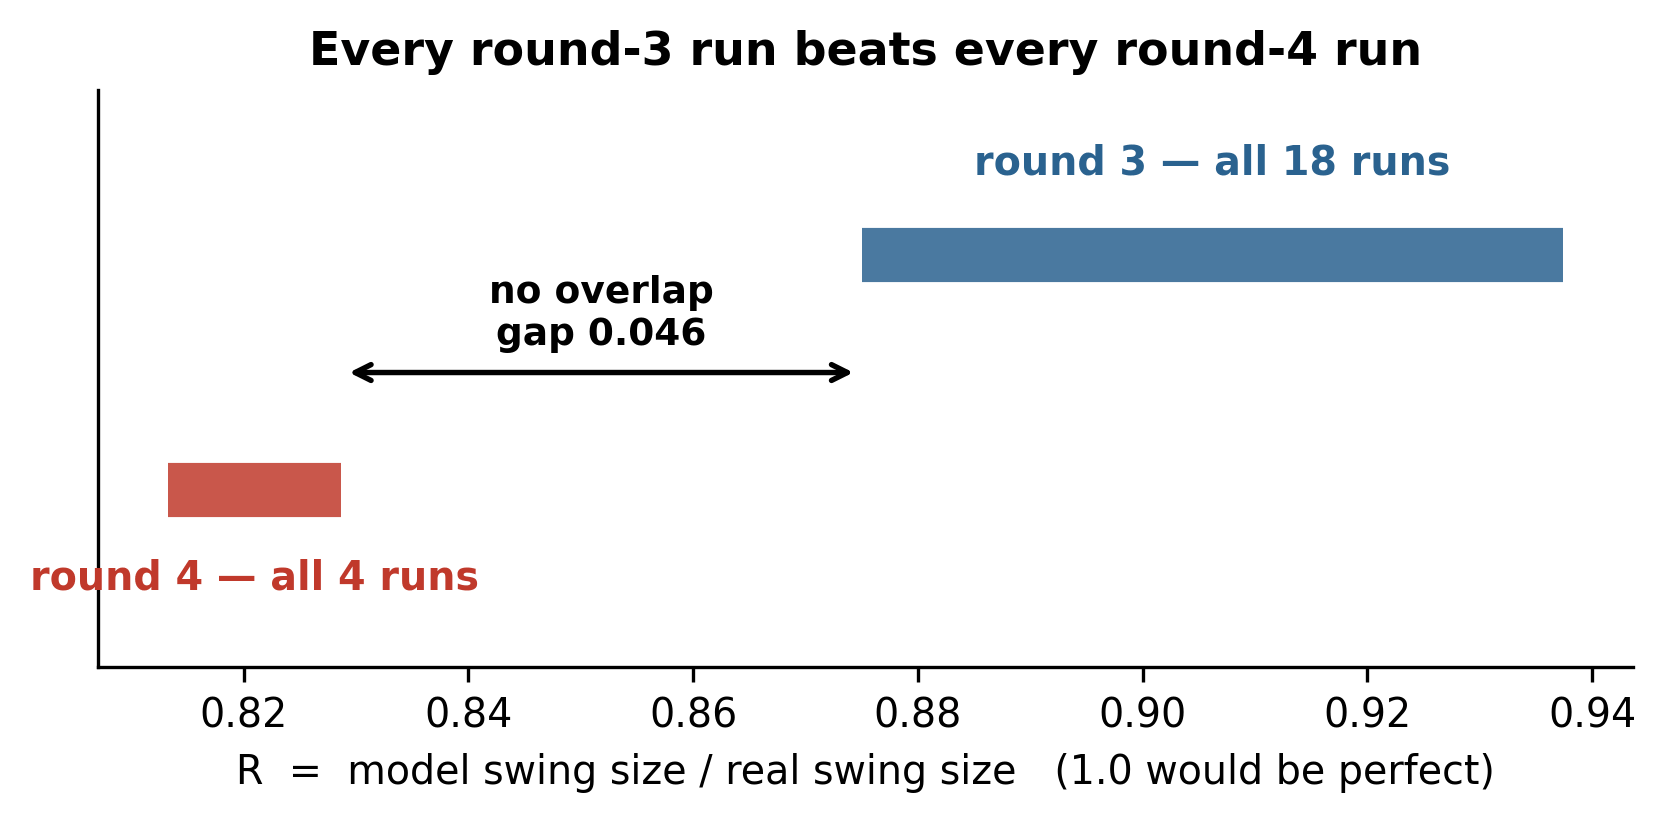

In [9]:
# t3_separation.png

**Figure 3 — The one piece of evidence with no
statistics in it.** Each bar spans all the individual runs we have of one model
version, where a "run" means generating the whole evaluation with one particular
random seed: 18 runs of round 3 in blue, 4 runs of
round 4 in red. R is the ratio of the model's price-swing size to the real
market's, so 1.0 would be perfect and lower means too calm. **The two ranges do
not overlap at all** — the worst round-3 run is still better than the best
round-4 run, with a gap of 0.046 between them. If round 4 were really
no different, the chance of the 4 round-4 runs all landing below
all 18 round-3 runs is 2 ÷ (22 choose 4) = **1 in 3,658**. This
uses no model, no degrees of freedom and no assumption about independence, which
is exactly why it is the number to quote when the parametric tests are in
dispute.

---

## Now the part that changes what we do next

We had blamed **the reweighting**. Here is what reweighting means, in one line.

> Round 4 looks at the sequences the model generated and says: *"you don't
> generate enough of the volatile ones — I'll count those double when I train
> on you."* Those multipliers are the weights.

The obvious control: **run the round again with all the weights set to 1.**
Same data, same 4,800 training steps, everything else identical — but no
reweighting at all.

If the reweighting was the culprit, this should come out fine.

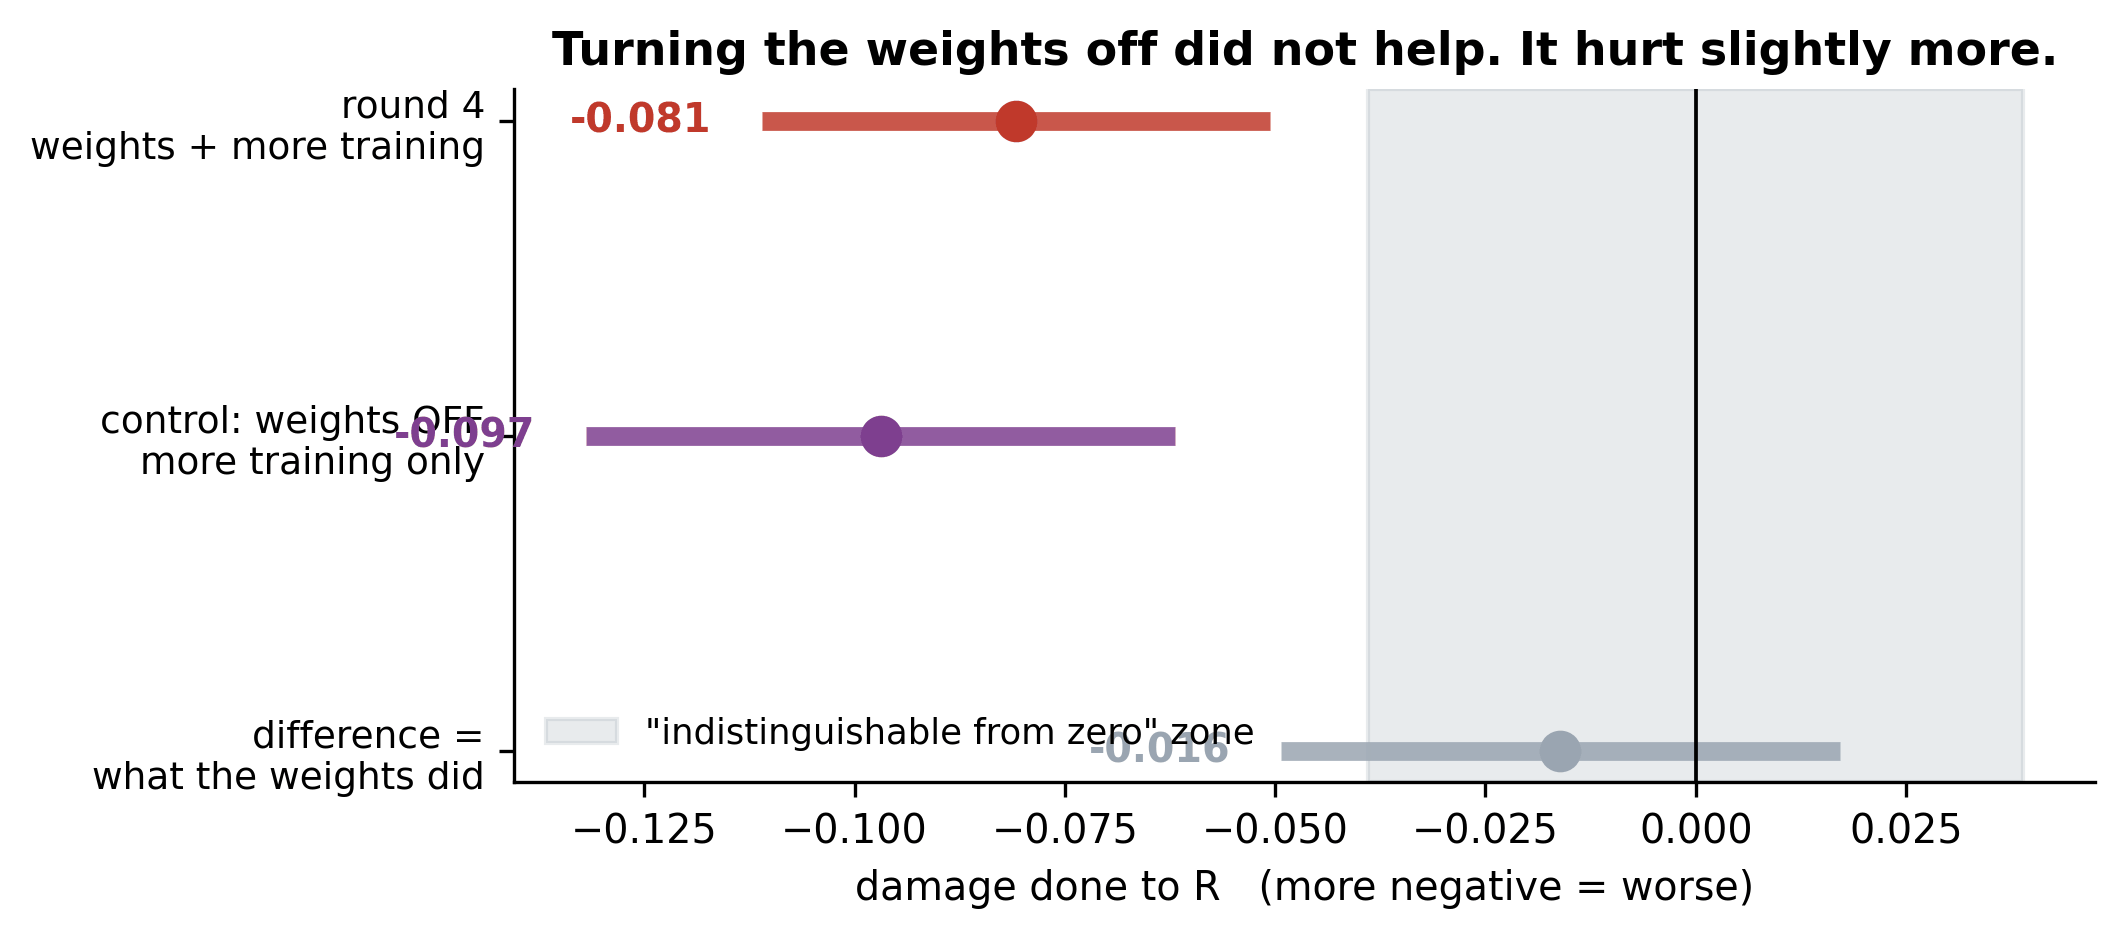

In [12]:
# t4_attribution.png

**Figure 4 — The control that reverses the
diagnosis.** Each bar is how much a training variant damaged R, the model's
price-swing ratio, with the horizontal line showing the 95% uncertainty range;
more negative means more damage. **Red** is round 4 as it was actually run —
new importance weights *plus* 4,800 extra training steps, the two changes we
never separated. **Purple** is a control we ran afterwards: identical in every
respect except that all importance weights were set to exactly 1, so it isolates
the extra training on its own. It damages R by -0.097,
which is *more* than round 4's -0.081,
on all 8 stocks. **Grey** is the difference between them, which is what the
weights themselves contributed: -0.016,
sitting inside the shaded zone where our own no-effect comparisons land, so it
cannot be told apart from zero. The extra training accounts for
120% of the damage; the reweighting we
blamed accounts for none of it that we can measure.

### What that means in practice

$\color{#c0392b}{\textsf{We wrote "the reweighting overshot" into the record.}}$
It is not what happened.

$\color{#2a628f}{\textsf{What the data says instead:}}$ **this training objective
degrades the model's price behaviour after about 9,600 cumulative steps, whatever
the weights are.**

That changes the next experiment from *"fix the weight estimator"* to *"find out
where the step budget runs out."* Those are different projects.

---

## The uncomfortable one: two of our three metrics are blind

We judge the model on three scores. Two of them, it turns out, **cannot see the
thing we claim to be measuring**.

The claim is that the model produces the right price behaviour **for the
situation it was given** — the right response to *this* morning's order book,
not just plausible-looking output in general.

Here is the test. Take the model's output, and **shuffle which real answer we
compare each generated window against.** Deliberately mismatch every prediction
with someone else's ground truth. Any score that measures "did you respond to
*this* situation correctly" must collapse.

> **Like grading essays by counting word frequencies.** Shuffle the essays
> between students and every grade stays exactly the same — which tells you the
> grade was never about the student.

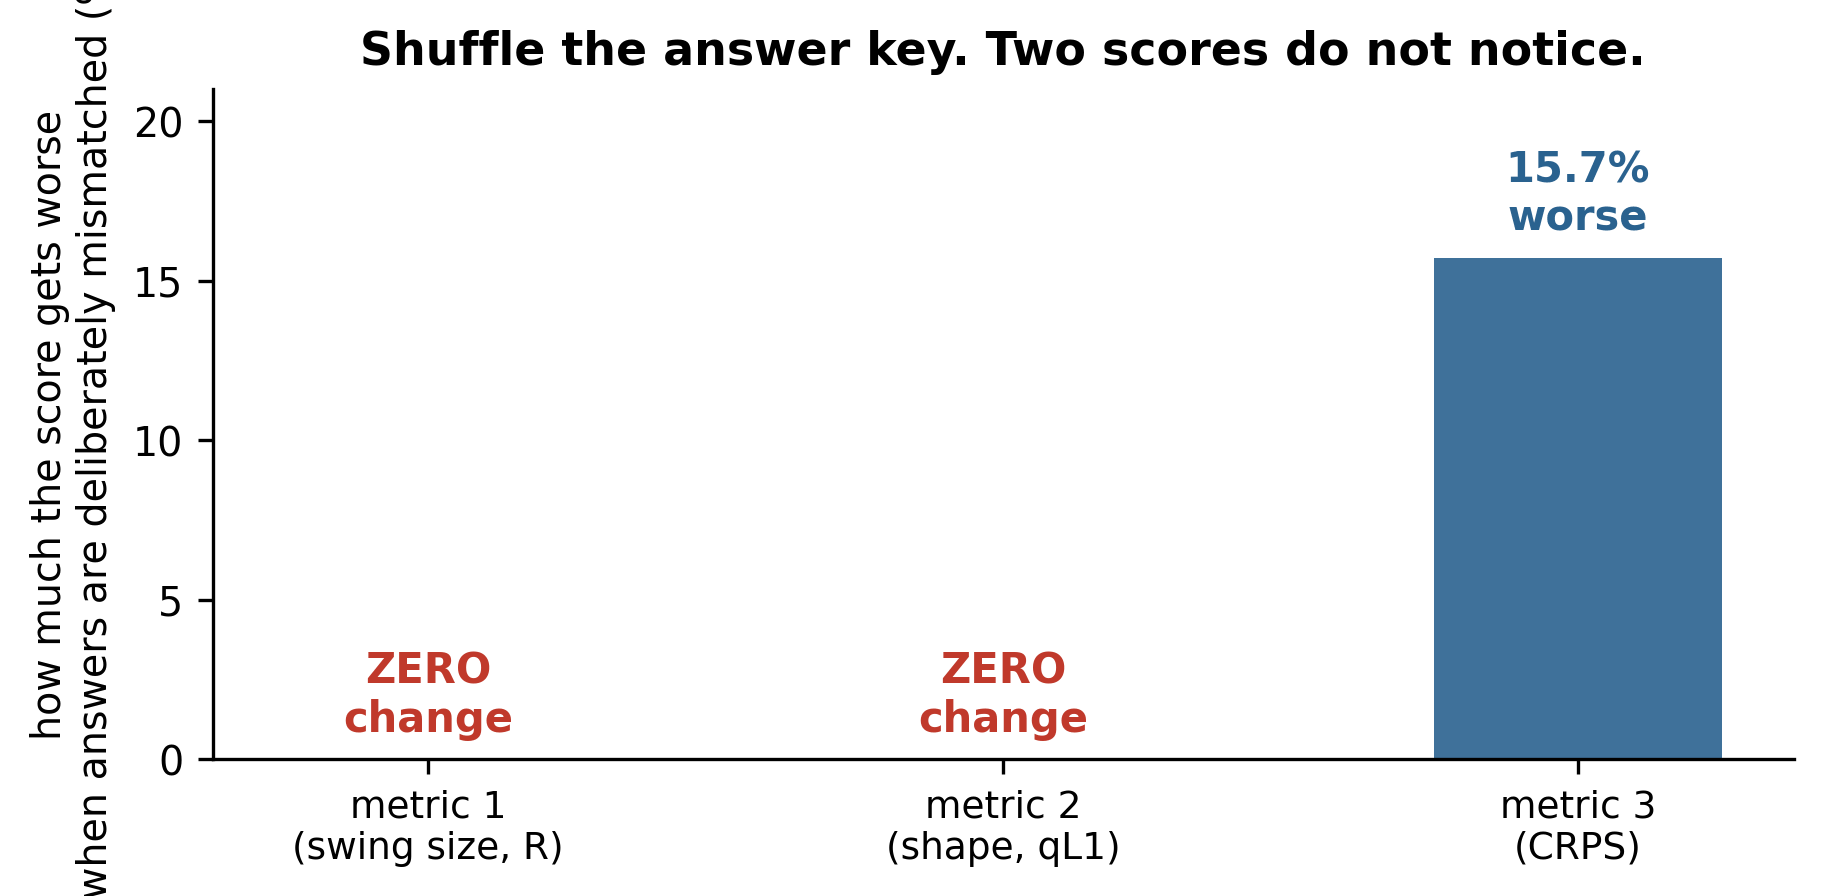

In [16]:
# t5_blind_metrics.png

**Figure 5 — Which of our three scores can
actually tell whether the model responded to the right situation.** We take every
generated window and deliberately pair it with a *different* window's real
outcome, shuffled within the same stock and the same trading day. A score that
measures conditional skill — "given this order book, did you produce the right
behaviour?" — must get worse when the answers are scrambled. **Metrics 1 and 2,
the two we have been reporting all along, do not change at all**: not
approximately, but to 0.0 and 2×10⁻¹⁶, because both are computed on all the
model's samples pooled together, discarding which window each came from. A model
that reproduced the overall market statistics while completely ignoring the
situation it was shown would score perfectly on both. **Only metric 3, CRPS, sees
it**, getting 15.7% worse under shuffling — which does confirm the model is
genuinely responding to its input. CRPS is also the score this whole project is
named after, and the one we had not been reporting.

---

## Where this leaves us

| | |
|---|---|
| $\color{#2a628f}{\textsf{Round 4 made the model worse}}$ | **holds** — no overlap between the two sets of runs, 1-in-3,658 by counting alone |
| $\color{#2a628f}{\textsf{The model responds to its input at all}}$ | **holds** — 13–16% worse when we scramble the answer key |
| $\color{#c0392b}{\textsf{"The reweighting overshot"}}$ | **wrong** — turning the weights off made it slightly worse, not better |
| $\color{#c0392b}{\textsf{t = −7.8}}$ | **wrong** — the test reports \|t\| = 6.9 on data with no effect in it; honest value ≈ −3.3 |
| $\color{#c98a1b}{\textsf{Does the procedure help at all?}}$ | **partly** — swing size and shape improve; CRPS, the score we are named for, does not clear the bar |
| $\color{#c98a1b}{\textsf{One training run per round}}$ | **open** — two replications are training now; until they land, every number is about *this checkpoint*, not *this method* |

<br>

### The one habit to take away

Three separate mistakes in two days had **the same shape**: we compared something
against a yardstick we had never checked.

> **Build a comparison whose answer you already know, and run your method on it
> first.**

It cost an afternoon. It changed a "certain" result into an uncertain one, an
uncertain one into a solid one, and a diagnosis into its opposite.